# Banking Operations — Exploratory Data Analysis

## Project 01 | Business Analytics Portfolio

### Objective
Explore a banking operations dataset to understand transaction volumes, processing times, errors, SLA breaches, product performance and regional patterns.

### Questions
- What does the dataset look like?
- Are there data-quality issues?
- Which products take the longest to process?
- Which products have more errors or SLA breaches?
- Do processing time and errors appear to be related?
- Are there any unusual revenue values?


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


## 2. Load the Dataset

In [2]:
df = pd.read_csv("data/raw/banking_operations_raw.csv")

df.head()


,Transaction_ID,Customer_ID,Product,Region,Processing_Time,Error_Count,SLA_Breach,Cost_Per_Txn,Revenue
0,TXN1001,C001,Credit Card,India,12 mins,0,No,50,250
1,TXN1002,C002,Loan,India,18 mins,1,No,120,600
2,TXN1003,C003,Mortgage,UK,45 mins,3,Yes,400,1500
3,TXN1004,C004,Credit Card,USA,15 mins,0,No,55,270
4,TXN1005,C005,Loans,India,22 mins,2,Yes,125,620


## 3. Understand the Dataset

In [3]:
df.shape


(31, 9)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction_ID   31 non-null     object
 1   Customer_ID      31 non-null     object
 2   Product          31 non-null     object
 3   Region           30 non-null     object
 4   Processing_Time  31 non-null     object
 5   Error_Count      31 non-null     int64 
 6   SLA_Breach       31 non-null     object
 7   Cost_Per_Txn     31 non-null     int64 
 8   Revenue          31 non-null     int64 
dtypes: int64(3), object(6)
memory usage: 2.3+ KB


In [5]:
df.describe()


,Error_Count,Cost_Per_Txn,Revenue
count,31.000000,31.000000,31.000000
mean,1.322581,144.000000,562.677419
std,2.135214,154.203977,568.162382
min,0.000000,18.000000,-500.000000
25%,0.000000,50.000000,247.500000
50%,0.000000,53.000000,260.000000
75%,2.000000,127.500000,625.000000
max,10.000000,430.000000,1550.000000


## 4. Check Data Quality

In [6]:
# Check missing values
df.isnull().sum()


Transaction_ID     0
Customer_ID        0
Product            0
Region             1
Processing_Time    0
Error_Count        0
SLA_Breach         0
Cost_Per_Txn       0
Revenue            0
dtype: int64

In [7]:
# Check duplicate rows
df.duplicated().sum()


np.int64(1)

In [8]:
# Check category values
print("Products:")
print(df["Product"].value_counts(dropna=False))

print("\nRegions:")
print(df["Region"].value_counts(dropna=False))

print("\nSLA Breach:")
print(df["SLA_Breach"].value_counts(dropna=False))


Products:
Product
Credit Card    11
Mortgage        7
Loan            6
Savings         5
Loans           1
Saving          1
Name: count, dtype: int64

Regions:
Region
India    17
USA       8
UK        4
U.K.      1
NaN       1
Name: count, dtype: int64

SLA Breach:
SLA_Breach
No     20
Yes    11
Name: count, dtype: int64


## 5. Clean the Data

There are a few simple inconsistencies in the categorical values. We will standardise them before analysis.

For missing Region values, we use `Unknown` rather than guessing the correct region.


In [9]:
data = df.copy()

# Standardise product names
data["Product"] = data["Product"].replace({
    "Saving": "Savings",
    "Loans": "Loan"
})

# Standardise region names
data["Region"] = data["Region"].replace({
    "U.K.": "UK"
})

# Keep missing regions visible
data["Region"] = data["Region"].fillna("Unknown")

# Convert processing time from text to minutes
data["Processing_Time_Min"] = (
    data["Processing_Time"].str.extract(r"(\d+)")[0].astype(int)
)

# Convert SLA breach to 0/1
data["SLA_Breach_Flag"] = data["SLA_Breach"].map({
    "Yes": 1,
    "No": 0
})

# Flag negative revenue
data["Negative_Revenue_Flag"] = data["Revenue"] < 0

# Remove duplicate rows
data = data.drop_duplicates()

data.head()


,Transaction_ID,Customer_ID,Product,Region,Processing_Time,Error_Count,SLA_Breach,Cost_Per_Txn,Revenue,Processing_Time_Min,SLA_Breach_Flag,Negative_Revenue_Flag
0,TXN1001,C001,Credit Card,India,12 mins,0,No,50,250,12,0,False
1,TXN1002,C002,Loan,India,18 mins,1,No,120,600,18,0,False
2,TXN1003,C003,Mortgage,UK,45 mins,3,Yes,400,1500,45,1,False
3,TXN1004,C004,Credit Card,USA,15 mins,0,No,55,270,15,0,False
4,TXN1005,C005,Loan,India,22 mins,2,Yes,125,620,22,1,False


## 6. Explore the Products

In [10]:
data["Product"].value_counts()


Product
Credit Card    10
Loan            7
Mortgage        7
Savings         6
Name: count, dtype: int64

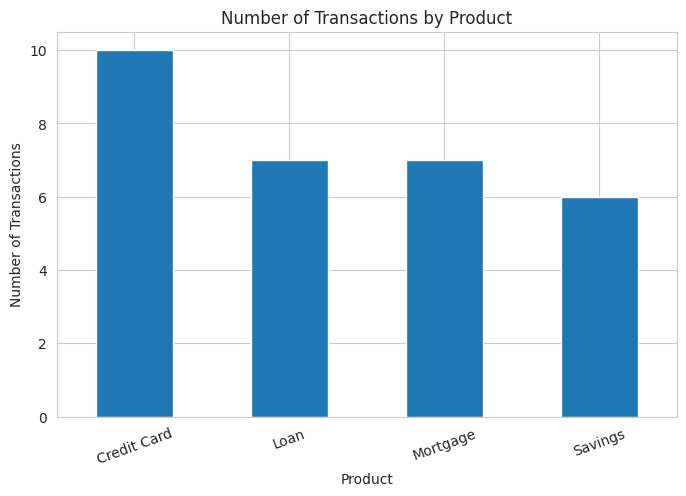

In [11]:
plt.figure(figsize=(8, 5))

data["Product"].value_counts().plot(kind="bar")

plt.title("Number of Transactions by Product")
plt.xlabel("Product")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.show()


## 7. Processing Time by Product

In [12]:
data.groupby("Product")["Processing_Time_Min"].mean().sort_values(ascending=False)


Product
Mortgage       112.142857
Credit Card     41.900000
Loan            22.142857
Savings          8.333333
Name: Processing_Time_Min, dtype: float64

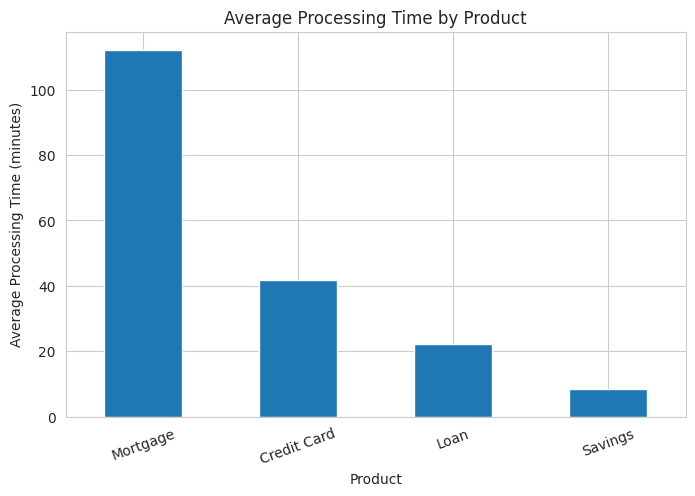

In [13]:
plt.figure(figsize=(8, 5))

avg_processing = data.groupby("Product")["Processing_Time_Min"].mean().sort_values(ascending=False)
avg_processing.plot(kind="bar")

plt.title("Average Processing Time by Product")
plt.xlabel("Product")
plt.ylabel("Average Processing Time (minutes)")
plt.xticks(rotation=20)
plt.show()


## 8. Errors by Product

In [14]:
data.groupby("Product")["Error_Count"].mean().sort_values(ascending=False)


Product
Mortgage       4.428571
Loan           1.428571
Credit Card    0.000000
Savings        0.000000
Name: Error_Count, dtype: float64

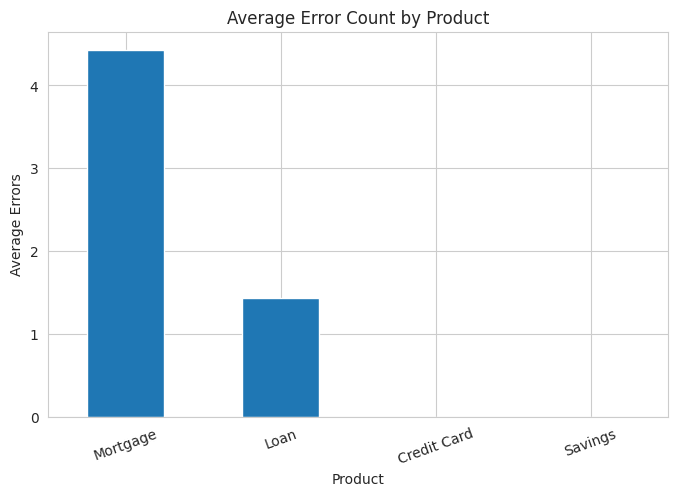

In [15]:
plt.figure(figsize=(8, 5))

avg_errors = data.groupby("Product")["Error_Count"].mean().sort_values(ascending=False)
avg_errors.plot(kind="bar")

plt.title("Average Error Count by Product")
plt.xlabel("Product")
plt.ylabel("Average Errors")
plt.xticks(rotation=20)
plt.show()


## 9. SLA Breaches

In [16]:
data.groupby("Product")["SLA_Breach_Flag"].mean().sort_values(ascending=False) * 100


Product
Mortgage       100.000000
Loan            42.857143
Credit Card     10.000000
Savings          0.000000
Name: SLA_Breach_Flag, dtype: float64

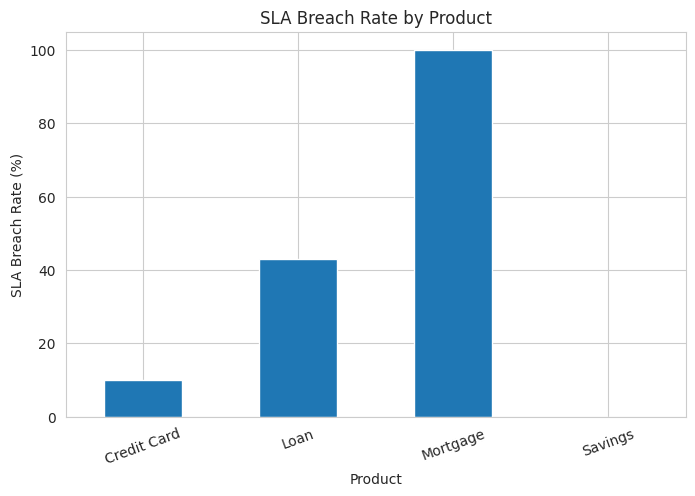

In [17]:
plt.figure(figsize=(8, 5))

sla_rate = data.groupby("Product")["SLA_Breach_Flag"].mean() * 100

sla_rate.plot(kind="bar")

plt.title("SLA Breach Rate by Product")
plt.xlabel("Product")
plt.ylabel("SLA Breach Rate (%)")
plt.xticks(rotation=20)
plt.show()


## 10. Regional Analysis

In [18]:
data.groupby("Region")["Processing_Time_Min"].mean().sort_values(ascending=False)


Region
USA        91.714286
UK         45.200000
India      31.117647
Unknown    12.000000
Name: Processing_Time_Min, dtype: float64

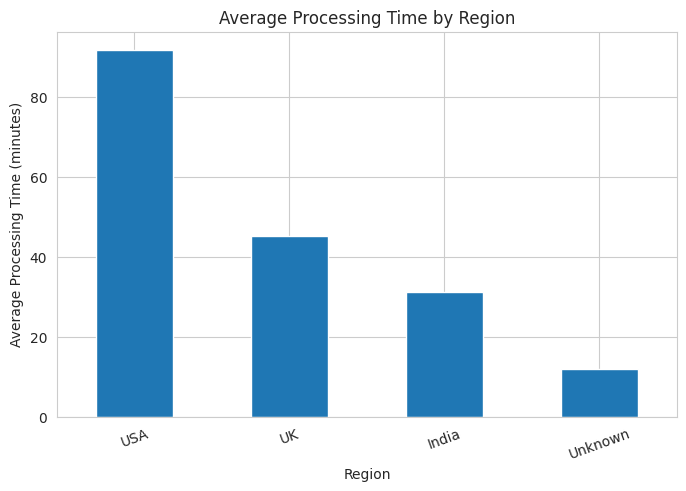

In [19]:
plt.figure(figsize=(8, 5))

avg_processing_region = data.groupby("Region")["Processing_Time_Min"].mean().sort_values(ascending=False)
avg_processing_region.plot(kind="bar")

plt.title("Average Processing Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Processing Time (minutes)")
plt.xticks(rotation=20)
plt.show()


## 11. Processing Time and Errors

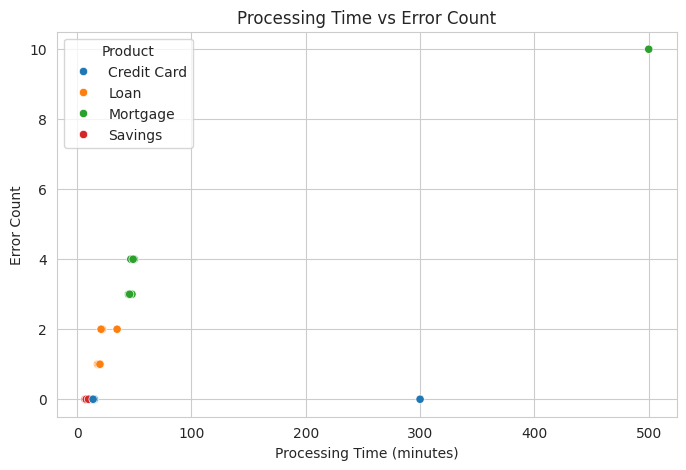

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="Processing_Time_Min",
    y="Error_Count",
    hue="Product"
)

plt.title("Processing Time vs Error Count")
plt.xlabel("Processing Time (minutes)")
plt.ylabel("Error Count")
plt.show()


## 12. Revenue Check

In [21]:
data[data["Revenue"] < 0][
    ["Transaction_ID", "Product", "Region", "Revenue", "Cost_Per_Txn"]
]


,Transaction_ID,Product,Region,Revenue,Cost_Per_Txn
21,TXN1021,Credit Card,India,-500,50


The negative revenue value is flagged for investigation rather than removed.

The dataset does not explain whether negative revenue represents a refund, reversal, chargeback or data-entry issue, so changing the value would require an unsupported assumption.


## 13. Key Findings

### Key observations

1. **Mortgage has the longest average processing time** and appears to be the most operationally complex product in the sample.
2. **Mortgage also has the highest average error count**, suggesting that longer processing may be associated with greater operational complexity.
3. **SLA breaches are concentrated in the higher-processing-time products.**
4. **Regional processing times differ**, although the dataset is too small to draw strong conclusions about regional performance.
5. **A negative revenue transaction exists** and should be investigated before using revenue data for profitability reporting.
6. The dataset also contains **inconsistent category labels and missing region information**, demonstrating the importance of data-quality checks before analysis.


## 14. Business Recommendations

- Investigate the Mortgage process to identify the steps causing longer processing times and higher error counts.
- Review SLA-breaching transactions to understand the operational reasons behind the delays.
- Standardise product and region values at the source to reduce future data-cleaning effort.
- Investigate the negative revenue transaction before using the dataset for financial reporting.
- With a larger dataset, analyse processing time by workflow stage, team and transaction complexity.


## 15. What I Learned

This project covers the foundations of Exploratory Data Analysis:

- Loading a dataset with Pandas
- Understanding rows, columns and data types
- Checking missing values and duplicates
- Cleaning categorical data
- Creating simple derived columns
- Using `groupby()` for business analysis
- Creating basic charts with Matplotlib and Seaborn
- Looking for relationships between variables
- Translating analysis into business observations

### Next progression

Future EDA projects will build on these foundations with more advanced statistical analysis, stronger visual storytelling, deeper anomaly analysis and more sophisticated business questions.
